# 1. Import libraries

This notebook builds an exploratory baseline for UIT-VSFC Vietnamese student feedback classification. It first checks the dataset structure and label balance, then trains two traditional machine-learning baselines for sentiment and topic prediction.

In [2]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score, 
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, DataCollatorWithPadding
from underthesea import word_tokenize

Set a fixed random seed so cross-validation splits and model initialization are more reproducible across runs.

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Apple MPS can be faster, but PhoBERT often runs out of memory on small shared-memory Macs.
USE_MPS = False

if torch.cuda.is_available():
    device = torch.device("cuda")
elif USE_MPS and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.empty_cache()

def clear_model_from_memory(*names):
    for name in names:
        if name in globals():
            del globals()[name]
    clear_device_cache()

def clone_state_dict_to_cpu(model):
    return {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

def load_best_state(model, state_dict, metric_name):
    if state_dict is None:
        raise RuntimeError(f"No best {metric_name} state was saved. Check the training loop before loading.")
    model.load_state_dict(state_dict)
    return model.to(device)

Using device: cpu


# 2. Load data

Each dataset split contains aligned files: `sents.txt` stores the feedback text, `sentiments.txt` stores sentiment labels, and `topics.txt` stores topic labels. The assertion below protects against accidental row misalignment between these files.

In [4]:
def read_lines(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f]
    
def load_split(DATA_DIR):
    sents = read_lines(os.path.join(DATA_DIR, 'sents.txt'))
    sentiments = read_lines(os.path.join(DATA_DIR, 'sentiments.txt'))
    topics = read_lines(os.path.join(DATA_DIR, 'topics.txt'))

    sentiments = [int(s) for s in sentiments]
    topics = [int(t) for t in topics]

    assert len(sents) == len(sentiments) == len(topics), f"Length mismatch in {DATA_DIR}"

    df = pd.DataFrame({
        'sentence': sents,
        'sentiment': sentiments,
        'topic': topics,
        "data_dir": DATA_DIR,
    })
    return df

train_df = load_split('train')
dev_df = load_split('dev')
test_df = load_split('test')

print(train_df.shape)
print(dev_df.shape)
print(test_df.shape)

train_df.head()

(11426, 4)
(1583, 4)
(3166, 4)


,sentence,sentiment,topic,data_dir
0,slide giáo trình đầy đủ .,2,1,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,train


Merge train, dev, and test splits for corpus-level exploratory data analysis. Model training below still uses the train split only, so the dev/test rows are not leaked into cross-validation.

In [5]:
all_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
all_df.head()

,sentence,sentiment,topic,data_dir
0,slide giáo trình đầy đủ .,2,1,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,train


# 3. Label mapping

The label maps convert numeric annotations into readable class names for tables and plots.

In [6]:
sentiment_map = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

topic_map = {
    0: 'lecturer',
    1: 'training program',
    2: 'facility',
    3: 'others'
}

# 4. EDA

## 4.1. Dataset size

In [7]:
print("Train:", len(train_df))
print("Dev:", len(dev_df))
print("Test:", len(test_df))

Train: 11426
Dev: 1583
Test: 3166


## 4.2. Label distribution

In [8]:
def show_distribution(df, column, label_map):
    counts = df[column].value_counts().sort_index()
    result = pd.DataFrame({
        'label_id': counts.index,
        'label_name': [label_map[i] for i in counts.index],
        'count': counts.values,
        'percentage': (counts.values / len(df) * 100).round(2)
    })
    return result

show_distribution(train_df, 'sentiment', sentiment_map)

,label_id,label_name,count,percentage
0,0,negative,5325,46.60
1,1,neutral,458,4.01
2,2,positive,5643,49.39


The sentiment labels are dominated by negative and positive feedback, while neutral feedback is rare at about 4% of the training set. Accuracy alone can therefore hide poor neutral-class performance, so macro precision/recall/F1 are important evaluation metrics.

In [9]:
show_distribution(train_df, "topic", topic_map)

,label_id,label_name,count,percentage
0,0,lecturer,8166,71.47
1,1,training program,2201,19.26
2,2,facility,497,4.35
3,3,others,562,4.92


The topic task is more imbalanced than sentiment classification: the lecturer class accounts for more than 70% of the training data, while facility and others are each below 5%. This increases the risk that a model learns the majority topic well but performs weakly on minority topics.

## 4.3. Plot distribution

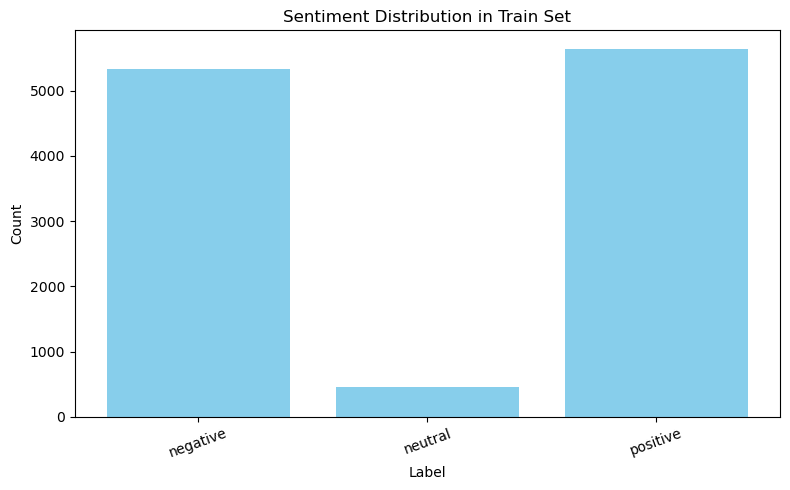

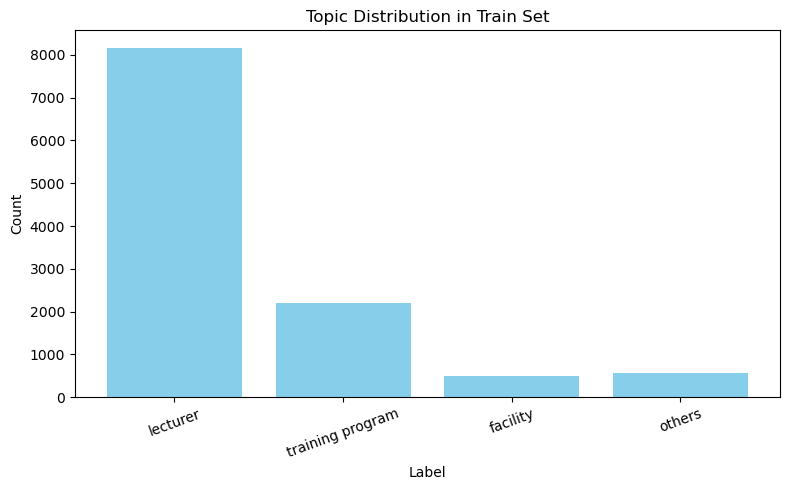

In [10]:
def plot_distribution(df, column, label_map, title):
    counts = df[column].value_counts().sort_index()
    labels = [label_map[i] for i in counts.index]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts.values, color='skyblue')
    plt.title(title)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

plot_distribution(train_df, 'sentiment', sentiment_map, 'Sentiment Distribution in Train Set')
plot_distribution(train_df, 'topic', topic_map, 'Topic Distribution in Train Set')

## 4.4. Sentence length

count    16175.000000
mean        14.229181
std         10.103769
min          2.000000
25%          8.000000
50%         11.000000
75%         17.000000
max        161.000000
Name: word_count, dtype: float64


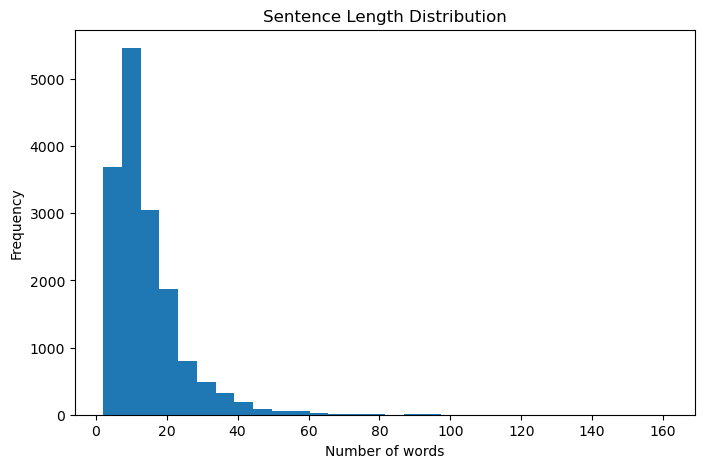

In [11]:
all_df["word_count"] = all_df["sentence"].apply(lambda x: len(x.split()))

print(all_df["word_count"].describe())

plt.figure(figsize=(8, 5))
plt.hist(all_df["word_count"], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Across all splits, the corpus contains 16,175 sentences with an average length of approximately 14.23 whitespace-tokenized words. The median sentence length is 11 words, while 75% of sentences contain 17 words or fewer. The distribution is positively skewed, so most comments are short and a small number of long comments act as outliers.

# 5. Baseline: Naive Bayes + Maximum Entropy

The baseline uses Vietnamese word segmentation, TF-IDF unigram/bigram features, and 5-fold stratified cross-validation on the training split. Naive Bayes gives a simple probabilistic benchmark, while Maximum Entropy is implemented as logistic regression with balanced class weights to reduce majority-class bias.

In [12]:
baseline_models = {
    "Naive Bayes": MultinomialNB(),
    "Maximum Entropy": LogisticRegression(max_iter=1000, class_weight='balanced'),
}

In [13]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "precision_weighted": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall_weighted": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
}

In [14]:
# Vietnamese word segmentation keeps compound words such as "giáo_trình" together for TF-IDF.
def vietnamese_tokenize(text):
    return word_tokenize(str(text), format="text")

train_df["tokenized_sentence"] = train_df["sentence"].apply(vietnamese_tokenize)
train_df[["sentence", "tokenized_sentence"]].head()

,sentence,tokenized_sentence
0,slide giáo trình đầy đủ .,slide giáo_trình đầy_đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt_tình giảng_dạy , gần_gũi với sinh_viên ."
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy_đủ full_điểm chuyên cần .
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...","thầy giảng bài hay , có nhiều bài_tập ví_dụ ng..."


In [15]:
def run_five_fold_cv(texts, labels, task_name):
    results = []

    # Stratification keeps each fold's class distribution close to the full training split.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model in baseline_models.items():
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=20000, 
                                      ngram_range=(1, 2), 
                                      lowercase=True)),
            ('classifier', model)
        ])

        scores = cross_validate(pipeline, texts, labels, cv=cv, scoring=scoring, return_train_score=False)
        results.append({
            "Task name": task_name,
            "Model": model_name,
            "Accuracy": np.mean(scores["test_accuracy"]),
            "Macro-precision": np.mean(scores["test_precision_macro"]),
            "Macro-recall": np.mean(scores["test_recall_macro"]),
            "Macro-F1": np.mean(scores["test_f1_macro"]),
            "Weighted-precision": np.mean(scores["test_precision_weighted"]),
            "Weighted-recall": np.mean(scores["test_recall_weighted"]),
            "Weighted-F1": np.mean(scores["test_f1_weighted"]) 
        })

    return pd.DataFrame(results)

In [16]:
sentiment_cv_results = run_five_fold_cv(
    train_df["tokenized_sentence"].tolist(),
    train_df["sentiment"].values,
    task_name="Sentiment Classification"
)

sentiment_cv_results

,Task name,Model,Accuracy,Macro-precision,Macro-recall,Macro-F1,Weighted-precision,Weighted-recall,Weighted-F1
0,Sentiment Classification,Naive Bayes,0.883511,0.590508,0.614185,0.601117,0.851449,0.883511,0.865750
1,Sentiment Classification,Maximum Entropy,0.885174,0.711802,0.747072,0.723838,0.899594,0.885174,0.891085


In [17]:
topic_cv_results = run_five_fold_cv(
    train_df["tokenized_sentence"].tolist(),
    train_df["topic"].values,
    task_name="Topic Classification"
)

topic_cv_results

,Task name,Model,Accuracy,Macro-precision,Macro-recall,Macro-F1,Weighted-precision,Weighted-recall,Weighted-F1
0,Topic Classification,Naive Bayes,0.766322,0.634374,0.379845,0.416544,0.739364,0.766322,0.701022
1,Topic Classification,Maximum Entropy,0.824785,0.711002,0.768957,0.731125,0.859387,0.824785,0.835920


In [18]:
baseline_cv_results = pd.concat(
    [sentiment_cv_results, topic_cv_results],
    ignore_index=True
)

baseline_cv_results

,Task name,Model,Accuracy,Macro-precision,Macro-recall,Macro-F1,Weighted-precision,Weighted-recall,Weighted-F1
0,Sentiment Classification,Naive Bayes,0.883511,0.590508,0.614185,0.601117,0.851449,0.883511,0.865750
1,Sentiment Classification,Maximum Entropy,0.885174,0.711802,0.747072,0.723838,0.899594,0.885174,0.891085
2,Topic Classification,Naive Bayes,0.766322,0.634374,0.379845,0.416544,0.739364,0.766322,0.701022
3,Topic Classification,Maximum Entropy,0.824785,0.711002,0.768957,0.731125,0.859387,0.824785,0.835920


In [21]:
baseline_cv_results_rounded = baseline_cv_results.copy()

metric_cols = [
    "Accuracy", "Macro-precision", "Macro-recall", "Macro-F1", "Weighted-precision", "Weighted-recall", "Weighted-F1"
]

baseline_cv_results_rounded[metric_cols] = baseline_cv_results_rounded[metric_cols].round(2)

baseline_cv_results_rounded

,Task name,Model,Accuracy,Macro-precision,Macro-recall,Macro-F1,Weighted-precision,Weighted-recall,Weighted-F1
0,Sentiment Classification,Naive Bayes,0.88,0.59,0.61,0.60,0.85,0.88,0.87
1,Sentiment Classification,Maximum Entropy,0.89,0.71,0.75,0.72,0.90,0.89,0.89
2,Topic Classification,Naive Bayes,0.77,0.63,0.38,0.42,0.74,0.77,0.70
3,Topic Classification,Maximum Entropy,0.82,0.71,0.77,0.73,0.86,0.82,0.84


In [19]:
baseline_cv_results_rounded.to_csv("results/baseline_5fold_cv_results.csv", index=False)

# 6. Single-task PhoBERT

## 6.1. Load tokenizer

In [20]:
MODEL_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

## 6.2. Dataset class

In [21]:
lengths = []

for text in test_df["sentence"]:
    tokens = tokenizer.encode(vietnamese_tokenize(text))
    lengths.append(len(tokens))

print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("Max:", np.max(lengths))

Mean: 16.547378395451673
Median: 13.0
95th percentile: 37.0
Max: 102


Inspect the token length distribution after Vietnamese word segmentation for PhoBERT input.

In [22]:
class FeedbackSingleTaskDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True
        )
        encoding["labels"] = label

        return encoding

## 6.3. Training and evaluation functions

In [23]:
def train_single_task_one_epoch(model, dataloader, optimizer, device, loss_fn=None):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad(set_to_none=True)

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        logits = outputs.logits

        if loss_fn is None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        else:
            loss = loss_fn(logits, labels)

        # Computes gradients using backpropagation.
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
    return total_loss / len(dataloader)

In [24]:
def evaluate_single_task(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask =  batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy()) 
        
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) 
    weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "predictions": np.array(all_preds),
        "labels": np.array(all_labels)
    } 

## 6.4. Class weight function

Weighted cross entropy for imbalanced labels. This gives minority classes a larger loss contribution during training.

In [25]:
def get_class_weights(labels, num_classes):
    classes = np.arange(num_classes)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=labels
    )

    return torch.tensor(weights, dtype=torch.float).to(device)

## 6.5. Train single-task PhoBERT for sentiment

PhoBERT was pretrained on Vietnamese text that had already been word-segmented. The notebook therefore keeps the raw sentence columns for display and error analysis, then creates `phobert_sentence` with `underthesea.word_tokenize(..., format="text")` for all PhoBERT dataloaders and prediction helpers.

In [26]:
# PhoBERT was pretrained on word-segmented Vietnamese text, so use segmented input for all PhoBERT models.
for df in [train_df, dev_df, test_df]:
    if "phobert_sentence" not in df.columns:
        df["phobert_sentence"] = df["sentence"].apply(vietnamese_tokenize)

X_train_text = train_df["sentence"].tolist()
X_dev_text = dev_df["sentence"].tolist()
X_test_text = test_df["sentence"].tolist()

X_train_phobert_text = train_df["phobert_sentence"].tolist()
X_dev_phobert_text = dev_df["phobert_sentence"].tolist()
X_test_phobert_text = test_df["phobert_sentence"].tolist()

y_train_sentiment = train_df["sentiment"].values
y_dev_sentiment = dev_df["sentiment"].values
y_test_sentiment = test_df["sentiment"].values

y_train_topic = train_df["topic"].values
y_dev_topic = dev_df["topic"].values
y_test_topic = test_df["topic"].values

In [28]:
BATCH_SIZE = 8
MAX_LEN = 64
EPOCHS = 3
LR = 2e-5

train_sentiment_dataset = FeedbackSingleTaskDataset(
    X_train_phobert_text,
    y_train_sentiment,
    tokenizer,
    max_len=MAX_LEN
)

dev_sentiment_dataset = FeedbackSingleTaskDataset(
    X_dev_phobert_text,
    y_dev_sentiment,
    tokenizer,
    max_len=MAX_LEN
)

train_sentiment_loader = DataLoader(
    train_sentiment_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

dev_sentiment_loader = DataLoader(
    dev_sentiment_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

clear_model_from_memory("single_sentiment_model", "optimizer")

single_sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
).to(device)

sentiment_weights = get_class_weights(y_train_sentiment, num_classes=3)
sentiment_loss_fn = nn.CrossEntropyLoss(weight=sentiment_weights)

optimizer = AdamW(single_sentiment_model.parameters(), lr=LR)

best_sentiment_f1 = -np.inf
best_sentiment_state = None

for epoch in range(EPOCHS):
    train_loss = train_single_task_one_epoch(
        single_sentiment_model,
        train_sentiment_loader,
        optimizer,
        device,
        loss_fn=sentiment_loss_fn
    )

    dev_result = evaluate_single_task(
        single_sentiment_model,
        dev_sentiment_loader,
        device
    )

    print(f"Epoch {epoch + 1}")
    print("Train loss:", round(train_loss, 4))
    print("Dev accuracy:", round(dev_result["accuracy"], 4))
    print("Dev macro precision:", round(dev_result["macro_precision"], 4))
    print("Dev macro recall:", round(dev_result["macro_recall"], 4))
    print("Dev macro F1:", round(dev_result["macro_f1"], 4))
    print("Dev weighted precision:", round(dev_result["weighted_precision"], 4))
    print("Dev weighted recall:", round(dev_result["weighted_recall"], 4))
    print("Dev weighted F1:", round(dev_result["weighted_f1"], 4))
    print()

    if dev_result["macro_f1"] > best_sentiment_f1:
        best_sentiment_f1 = dev_result["macro_f1"]
        best_sentiment_state = clone_state_dict_to_cpu(single_sentiment_model)

clear_model_from_memory("optimizer")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RuntimeError: MPS backend out of memory (MPS allocated: 4.50 GiB, other allocations: 4.42 GiB, max allowed: 9.07 GiB). Tried to allocate 187.50 MiB on shared pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [ ]:
single_sentiment_model = load_best_state(single_sentiment_model, best_sentiment_state, "sentiment")

## 6.6. Train single task PhoBERT for topic

In [ ]:
train_topic_dataset = FeedbackSingleTaskDataset(
    X_train_phobert_text,
    y_train_topic,
    tokenizer,
    max_len=MAX_LEN
)

dev_topic_dataset = FeedbackSingleTaskDataset(
    X_dev_phobert_text,
    y_dev_topic,
    tokenizer,
    max_len=MAX_LEN
)

train_topic_loader = DataLoader(
    train_topic_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

dev_topic_loader = DataLoader(
    dev_topic_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

clear_model_from_memory("single_topic_model", "optimizer")

single_topic_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4
).to(device)

topic_weights = get_class_weights(y_train_topic, num_classes=4)
topic_loss_fn = nn.CrossEntropyLoss(weight=topic_weights)

optimizer = AdamW(single_topic_model.parameters(), lr=LR)

best_topic_f1 = -np.inf
best_topic_state = None

for epoch in range(EPOCHS):
    train_loss = train_single_task_one_epoch(
        single_topic_model,
        train_topic_loader,
        optimizer,
        device,
        loss_fn=topic_loss_fn
    )

    dev_result = evaluate_single_task(
        single_topic_model,
        dev_topic_loader,
        device
    )

    print(f"Epoch {epoch + 1}")
    print("Train loss:", round(train_loss, 4))
    print("Dev accuracy:", round(dev_result["accuracy"], 4))
    print("Dev macro precision:", round(dev_result["macro_precision"], 4))
    print("Dev macro recall:", round(dev_result["macro_recall"], 4))
    print("Dev macro F1:", round(dev_result["macro_f1"], 4))
    print("Dev weighted precision:", round(dev_result["weighted_precision"], 4))
    print("Dev weighted recall:", round(dev_result["weighted_recall"], 4))
    print("Dev weighted F1:", round(dev_result["weighted_f1"], 4))
    print()

    if dev_result["macro_f1"] > best_topic_f1:
        best_topic_f1 = dev_result["macro_f1"]
        best_topic_state = clone_state_dict_to_cpu(single_topic_model)

clear_model_from_memory("optimizer")

In [ ]:
single_topic_model = load_best_state(single_topic_model, best_topic_state, "topic")

# 7. Multitask PhoBERT + Weight cross entropy

## 7.1. Dataset class

In [ ]:
class FeedbackMultiTaskDataset(Dataset):
    def __init__(self, texts, sentiment_labels, topic_labels, tokenizer, max_len=64):
        self.texts = texts
        self.sentiment_labels = sentiment_labels
        self.topic_labels = topic_labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True
        )
        encoding["sentiment_label"] = int(self.sentiment_labels[idx])
        encoding["topic_label"] = int(self.topic_labels[idx])

        return encoding

## 7.2. Multitask model

In [ ]:
class PhoBERTMultiTask(nn.Module):
    def __init__(self, model_name, num_sentiment_labels=3, num_topic_labels=4, dropout=0.1):
        super().__init__()

        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.sentiment_classifier = nn.Linear(hidden_size, num_sentiment_labels)
        self.topic_classifier = nn.Linear(hidden_size, num_topic_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        sentiment_logits = self.sentiment_classifier(cls_embedding)
        topic_logits = self.topic_classifier(cls_embedding)

        return sentiment_logits, topic_logits

## 7.3. Create dataloaders

In [ ]:
train_multitask_dataset = FeedbackMultiTaskDataset(
    X_train_phobert_text,
    y_train_sentiment,
    y_train_topic,
    tokenizer,
    max_len=MAX_LEN
)

dev_multitask_dataset = FeedbackMultiTaskDataset(
    X_dev_phobert_text,
    y_dev_sentiment,
    y_dev_topic,
    tokenizer,
    max_len=MAX_LEN
)

train_multitask_loader = DataLoader(
    train_multitask_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

dev_multitask_loader = DataLoader(
    dev_multitask_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

## 7.4. Train function

In [ ]:
def train_multitask_one_epoch(
    model,
    data_loader,
    optimizer,
    device,
    sentiment_loss_fn,
    topic_loss_fn,
    alpha=1.0,
    beta=1.0
):
    model.train()
    total_loss = 0

    for batch in data_loader:
        optimizer.zero_grad(set_to_none=True)

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        sentiment_labels = batch["sentiment_label"].to(device)
        topic_labels = batch["topic_label"].to(device)

        sentiment_logits, topic_logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sentiment_loss = sentiment_loss_fn(sentiment_logits, sentiment_labels)
        topic_loss = topic_loss_fn(topic_logits, topic_labels)

        loss = alpha * sentiment_loss + beta * topic_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

## 7.5. Evaluation function

The multitask evaluator reports the same metric family used by the single-task models: accuracy, macro precision/recall/F1, and weighted precision/recall/F1 for both sentiment and topic prediction.

In [ ]:
def evaluate_multitask(model, data_loader, device):
    model.eval()

    sentiment_preds = []
    sentiment_true = []

    topic_preds = []
    topic_true = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            sentiment_labels = batch["sentiment_label"].to(device)
            topic_labels = batch["topic_label"].to(device)

            sentiment_logits, topic_logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            sent_preds = torch.argmax(sentiment_logits, dim=1)
            top_preds = torch.argmax(topic_logits, dim=1)

            sentiment_preds.extend(sent_preds.cpu().numpy())
            sentiment_true.extend(sentiment_labels.cpu().numpy())

            topic_preds.extend(top_preds.cpu().numpy())
            topic_true.extend(topic_labels.cpu().numpy())

    sentiment_acc = accuracy_score(sentiment_true, sentiment_preds)
    sentiment_macro_f1 = f1_score(sentiment_true, sentiment_preds, average="macro", zero_division=0)
    sentiment_weighted_f1 = f1_score(sentiment_true, sentiment_preds, average="weighted", zero_division=0)

    topic_acc = accuracy_score(topic_true, topic_preds)
    topic_macro_f1 = f1_score(topic_true, topic_preds, average="macro", zero_division=0)
    topic_weighted_f1 = f1_score(topic_true, topic_preds, average="weighted", zero_division=0)

    return {
        "sentiment_accuracy": sentiment_acc,
        "sentiment_macro_precision": precision_score(sentiment_true, sentiment_preds, average="macro", zero_division=0),
        "sentiment_macro_recall": recall_score(sentiment_true, sentiment_preds, average="macro", zero_division=0),
        "sentiment_macro_f1": sentiment_macro_f1,
        "sentiment_weighted_precision": precision_score(sentiment_true, sentiment_preds, average="weighted", zero_division=0),
        "sentiment_weighted_recall": recall_score(sentiment_true, sentiment_preds, average="weighted", zero_division=0),
        "sentiment_weighted_f1": sentiment_weighted_f1,
        "sentiment_predictions": np.array(sentiment_preds),
        "sentiment_labels": np.array(sentiment_true),

        "topic_accuracy": topic_acc,
        "topic_macro_precision": precision_score(topic_true, topic_preds, average="macro", zero_division=0),
        "topic_macro_recall": recall_score(topic_true, topic_preds, average="macro", zero_division=0),
        "topic_macro_f1": topic_macro_f1,
        "topic_weighted_precision": precision_score(topic_true, topic_preds, average="weighted", zero_division=0),
        "topic_weighted_recall": recall_score(topic_true, topic_preds, average="weighted", zero_division=0),
        "topic_weighted_f1": topic_weighted_f1,
        "topic_predictions": np.array(topic_preds),
        "topic_labels": np.array(topic_true)
    }

## 7.6. Train multitask model

In [ ]:
clear_model_from_memory("multitask_model", "optimizer")

multitask_model = PhoBERTMultiTask(MODEL_NAME).to(device)

sentiment_weights = get_class_weights(y_train_sentiment, num_classes=3)
topic_weights = get_class_weights(y_train_topic, num_classes=4)

sentiment_loss_fn = nn.CrossEntropyLoss(weight=sentiment_weights)
topic_loss_fn = nn.CrossEntropyLoss(weight=topic_weights)

optimizer = AdamW(multitask_model.parameters(), lr=LR)

best_multitask_score = -np.inf
best_multitask_state = None

for epoch in range(EPOCHS):
    train_loss = train_multitask_one_epoch(
        multitask_model,
        train_multitask_loader,
        optimizer,
        device,
        sentiment_loss_fn,
        topic_loss_fn,
        alpha=1.0,
        beta=1.0
    )

    dev_result = evaluate_multitask(
        multitask_model,
        dev_multitask_loader,
        device
    )

    combined_macro_f1 = (
        dev_result["sentiment_macro_f1"] + dev_result["topic_macro_f1"]
    ) / 2

    print(f"Epoch {epoch + 1}")
    print("Train loss:", round(train_loss, 4))
    
    print("Sentiment Dev Accuracy:", round(dev_result["sentiment_accuracy"], 4))
    print("Sentiment Dev Macro Precision:", round(dev_result["sentiment_macro_precision"], 4))
    print("Sentiment Dev Macro Recall:", round(dev_result["sentiment_macro_recall"], 4))
    print("Sentiment Dev Macro F1:", round(dev_result["sentiment_macro_f1"], 4))

    print("Sentiment Dev Weighted Precision:", round(dev_result["sentiment_weighted_precision"], 4))
    print("Sentiment Dev Weighted Recall:", round(dev_result["sentiment_weighted_recall"], 4))
    print("Sentiment Dev Weighted F1:", round(dev_result["sentiment_weighted_f1"], 4))

    print("Topic Dev Accuracy:", round(dev_result["topic_accuracy"], 4))
    print("Topic Dev Macro Precision:", round(dev_result["topic_macro_precision"], 4))
    print("Topic Dev Macro Recall:", round(dev_result["topic_macro_recall"], 4))
    print("Topic Dev Macro F1:", round(dev_result["topic_macro_f1"], 4))

    print("Topic Dev Weighted Precision:", round(dev_result["topic_weighted_precision"], 4))
    print("Topic Dev Weighted Recall:", round(dev_result["topic_weighted_recall"], 4))
    print("Topic Dev Weighted F1:", round(dev_result["topic_weighted_f1"], 4))

    print("Combined Macro F1:", round(combined_macro_f1, 4))
    print()

    if combined_macro_f1 > best_multitask_score:
        best_multitask_score = combined_macro_f1
        best_multitask_state = clone_state_dict_to_cpu(multitask_model)

clear_model_from_memory("optimizer")

In [ ]:
multitask_model = load_best_state(multitask_model, best_multitask_state, "multitask")

# 8. Final test evaluation

## 8.1. Single-task test datasets

In [ ]:
test_sentiment_dataset = FeedbackSingleTaskDataset(
    X_test_phobert_text,
    y_test_sentiment,
    tokenizer,
    max_len=MAX_LEN
)

test_sentiment_loader = DataLoader(
    test_sentiment_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

test_topic_dataset = FeedbackSingleTaskDataset(
    X_test_phobert_text,
    y_test_topic,
    tokenizer,
    max_len=MAX_LEN
)

test_topic_loader = DataLoader(
    test_topic_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

## 8.2. Evaluate single-task PhoBERT on test

In [ ]:
single_sentiment_test_result = evaluate_single_task(
    single_sentiment_model,
    test_sentiment_loader,
    device
)

print("Single-task PhoBERT - Sentiment Test")
print("Accuracy:", single_sentiment_test_result["accuracy"])
print("Macro Precision:", single_sentiment_test_result["macro_precision"])
print("Macro Recall:", single_sentiment_test_result["macro_recall"])
print("Macro F1:", single_sentiment_test_result["macro_f1"])
print("Weighted Precision:", single_sentiment_test_result["weighted_precision"])
print("Weighted Recall:", single_sentiment_test_result["weighted_recall"])
print("Weighted F1:", single_sentiment_test_result["weighted_f1"])
print(classification_report(
    single_sentiment_test_result["labels"],
    single_sentiment_test_result["predictions"],
    labels=sorted(sentiment_map.keys()),
    target_names=[sentiment_map[i] for i in sorted(sentiment_map.keys())],
    zero_division=0
))

In [ ]:
single_topic_test_result = evaluate_single_task(
    single_topic_model,
    test_topic_loader,
    device
)

print("Single-task PhoBERT - Topic Test")
print("Accuracy:", single_topic_test_result["accuracy"])
print("Macro Precision:", single_topic_test_result["macro_precision"])
print("Macro Recall:", single_topic_test_result["macro_recall"])
print("Macro F1:", single_topic_test_result["macro_f1"])
print("Weighted Precision:", single_topic_test_result["weighted_precision"])
print("Weighted Recall:", single_topic_test_result["weighted_recall"])
print("Weighted F1:", single_topic_test_result["weighted_f1"])
print(classification_report(
    single_topic_test_result["labels"],
    single_topic_test_result["predictions"],
    labels=sorted(topic_map.keys()),
    target_names=[topic_map[i] for i in sorted(topic_map.keys())],
    zero_division=0
))

## 8.3. Multitask test dataset

In [ ]:
test_multitask_dataset = FeedbackMultiTaskDataset(
    X_test_phobert_text,
    y_test_sentiment,
    y_test_topic,
    tokenizer,
    max_len=MAX_LEN
)

test_multitask_loader = DataLoader(
    test_multitask_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
)

## 8.4. Evaluate multitask on test

In [ ]:
multitask_test_result = evaluate_multitask(
    multitask_model,
    test_multitask_loader,
    device
)

print("Multitask PhoBERT - Sentiment Test")
print("Accuracy:", multitask_test_result["sentiment_accuracy"])
print("Macro Precision:", multitask_test_result["sentiment_macro_precision"])
print("Macro Recall:", multitask_test_result["sentiment_macro_recall"])
print("Macro F1:", multitask_test_result["sentiment_macro_f1"])
print("Weighted Precision:", multitask_test_result["sentiment_weighted_precision"])
print("Weighted Recall:", multitask_test_result["sentiment_weighted_recall"])
print("Weighted F1:", multitask_test_result["sentiment_weighted_f1"])
print(classification_report(
    multitask_test_result["sentiment_labels"],
    multitask_test_result["sentiment_predictions"],
    labels=sorted(sentiment_map.keys()),
    target_names=[sentiment_map[i] for i in sorted(sentiment_map.keys())],
    zero_division=0
))

print("Multitask PhoBERT - Topic Test")
print("Accuracy:", multitask_test_result["topic_accuracy"])
print("Macro Precision:", multitask_test_result["topic_macro_precision"])
print("Macro Recall:", multitask_test_result["topic_macro_recall"])
print("Macro F1:", multitask_test_result["topic_macro_f1"])
print("Weighted Precision:", multitask_test_result["topic_weighted_precision"])
print("Weighted Recall:", multitask_test_result["topic_weighted_recall"])
print("Weighted F1:", multitask_test_result["topic_weighted_f1"])
print(classification_report(
    multitask_test_result["topic_labels"],
    multitask_test_result["topic_predictions"],
    labels=sorted(topic_map.keys()),
    target_names=[topic_map[i] for i in sorted(topic_map.keys())],
    zero_division=0
))

# 9. Baseline test evaluation

This section evaluates the same traditional baselines used in Part 5: Naive Bayes and Maximum Entropy. Each baseline is retrained on the full training split, then evaluated once on the held-out test split with the same macro and weighted metrics used for the PhoBERT models.

In [ ]:
def evaluate_sklearn_model(model, X, y_true, label_map, title="Model"):
    y_pred = model.predict(X)

    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "predictions": np.array(y_pred),
        "labels": np.array(y_true)
    }

    print(f"{title}")
    print("Accuracy:", round(result["accuracy"], 4))
    print("Macro Precision:", round(result["macro_precision"], 4))
    print("Macro Recall:", round(result["macro_recall"], 4))
    print("Macro F1:", round(result["macro_f1"], 4))
    print("Weighted Precision:", round(result["weighted_precision"], 4))
    print("Weighted Recall:", round(result["weighted_recall"], 4))
    print("Weighted F1:", round(result["weighted_f1"], 4))
    print()

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]
    print(classification_report(y_true, y_pred, labels=labels, target_names=target_names, zero_division=0))

    return result

In [ ]:
if "tokenized_sentence" not in train_df.columns:
    train_df["tokenized_sentence"] = train_df["sentence"].apply(vietnamese_tokenize)

test_df["tokenized_sentence"] = test_df["sentence"].apply(vietnamese_tokenize)

baseline_model_builders = {
    "Naive Bayes": lambda: MultinomialNB(),
    "Maximum Entropy": lambda: LogisticRegression(max_iter=1000, class_weight="balanced"),
}

baseline_test_results = {"Sentiment": {}, "Topic": {}}

for model_name, build_model in baseline_model_builders.items():
    sentiment_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), lowercase=True)),
        ("classifier", build_model())
    ])
    sentiment_pipeline.fit(train_df["tokenized_sentence"].tolist(), train_df["sentiment"].values)
    baseline_test_results["Sentiment"][model_name] = evaluate_sklearn_model(
        sentiment_pipeline,
        test_df["tokenized_sentence"].tolist(),
        test_df["sentiment"].values,
        sentiment_map,
        title=f"TF-IDF + {model_name} - Sentiment Test"
    )

    topic_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), lowercase=True)),
        ("classifier", build_model())
    ])
    topic_pipeline.fit(train_df["tokenized_sentence"].tolist(), train_df["topic"].values)
    baseline_test_results["Topic"][model_name] = evaluate_sklearn_model(
        topic_pipeline,
        test_df["tokenized_sentence"].tolist(),
        test_df["topic"].values,
        topic_map,
        title=f"TF-IDF + {model_name} - Topic Test"
    )

nb_sentiment_test_result = baseline_test_results["Sentiment"]["Naive Bayes"]
maxent_sentiment_test_result = baseline_test_results["Sentiment"]["Maximum Entropy"]
nb_topic_test_result = baseline_test_results["Topic"]["Naive Bayes"]
maxent_topic_test_result = baseline_test_results["Topic"]["Maximum Entropy"]

# 10. Final comparison table

The final table uses the same test metrics from Part 9 for every model family. Macro metrics show class-balanced performance, while weighted metrics show performance after accounting for each class frequency.

In [ ]:
def make_result_row(task, model_name, result, prefix=None):
    def metric_key(metric):
        return f"{prefix}_{metric}" if prefix else metric

    return {
        "Task": task,
        "Model": model_name,
        "Test Accuracy": result[metric_key("accuracy")],
        "Test Macro Precision": result[metric_key("macro_precision")],
        "Test Macro Recall": result[metric_key("macro_recall")],
        "Test Macro F1": result[metric_key("macro_f1")],
        "Test Weighted Precision": result[metric_key("weighted_precision")],
        "Test Weighted Recall": result[metric_key("weighted_recall")],
        "Test Weighted F1": result[metric_key("weighted_f1")]
    }

results_table = pd.DataFrame([
    make_result_row("Sentiment", "TF-IDF + Naive Bayes", nb_sentiment_test_result),
    make_result_row("Sentiment", "TF-IDF + Maximum Entropy", maxent_sentiment_test_result),
    make_result_row("Sentiment", "Single-task PhoBERT", single_sentiment_test_result),
    make_result_row("Sentiment", "Multitask PhoBERT", multitask_test_result, prefix="sentiment"),
    make_result_row("Topic", "TF-IDF + Naive Bayes", nb_topic_test_result),
    make_result_row("Topic", "TF-IDF + Maximum Entropy", maxent_topic_test_result),
    make_result_row("Topic", "Single-task PhoBERT", single_topic_test_result),
    make_result_row("Topic", "Multitask PhoBERT", multitask_test_result, prefix="topic"),
])

metric_cols = [col for col in results_table.columns if col.startswith("Test")]
results_table[metric_cols] = results_table[metric_cols].round(2)

results_table

In [ ]:
results_table.to_csv("results/final_results.csv", index=False)

In [4]:
final_results = pd.read_csv("results/final_results.csv").round(2)
final_results

,Task,Model,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted Precision,Test Weighted Recall,Test Weighted F1
0,Sentiment,TF-IDF + Naive Bayes,0.87,0.58,0.61,0.59,0.83,0.87,0.84
1,Sentiment,TF-IDF + Maximum Entropy,0.87,0.71,0.73,0.71,0.88,0.87,0.87
2,Sentiment,Single-task PhoBERT,0.93,0.83,0.86,0.84,0.94,0.93,0.93
3,Sentiment,Multitask PhoBERT,0.93,0.83,0.83,0.83,0.93,0.93,0.93
4,Topic,TF-IDF + Naive Bayes,0.79,0.64,0.42,0.47,0.75,0.79,0.74
5,Topic,TF-IDF + Maximum Entropy,0.81,0.69,0.76,0.71,0.85,0.81,0.82
6,Topic,Single-task PhoBERT,0.85,0.74,0.84,0.77,0.89,0.85,0.86
7,Topic,Multitask PhoBERT,0.84,0.71,0.83,0.75,0.88,0.84,0.85


# 11. Confusion matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, label_map, title, save_dir="confusion_matrices"):
    labels = sorted(label_map.keys())
    display_labels = [label_map[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)

    os.makedirs(save_dir, exist_ok=True)
    safe_title = title.lower().replace(" ", "_").replace("-", "_")
    safe_title = "".join(ch if ch.isalnum() or ch == "_" else "_" for ch in safe_title)
    csv_path = os.path.join(save_dir, f"{safe_title}.csv")
    png_path = os.path.join(save_dir, f"{safe_title}.png")
    cm_df.to_csv(csv_path)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved confusion matrix to {png_path} and {csv_path}")
    plt.show()

    return cm_df

# 12. Error analysis

## 12.1. Sentiment error

In [ ]:
def get_error_examples(texts, y_true, y_pred, label_map, max_examples=20):
    errors = []

    for text, true_label, pred_label in zip(texts, y_true, y_pred):
        if true_label != pred_label:
            errors.append({
                "sentence": text,
                "true_label": label_map[int(true_label)],
                "predicted_label": label_map[int(pred_label)]
            })

    return pd.DataFrame(errors).head(max_examples)

In [ ]:
sentiment_errors = get_error_examples(
    X_test_text,
    single_sentiment_test_result["labels"],
    single_sentiment_test_result["predictions"],
    sentiment_map,
    max_examples=30
)

sentiment_errors

In [ ]:
plot_confusion_matrix(
    single_sentiment_test_result["labels"],
    single_sentiment_test_result["predictions"],
    sentiment_map,
    "Single-task PhoBERT Sentiment Confusion Matrix"
)

In [ ]:
plot_confusion_matrix(
    multitask_test_result["sentiment_labels"],
    multitask_test_result["sentiment_predictions"],
    sentiment_map,
    "Multitask PhoBERT Sentiment Confusion Matrix"
)

## 12.2. Topic error

In [ ]:
topic_errors = get_error_examples(
    X_test_text,
    multitask_test_result["topic_labels"],
    multitask_test_result["topic_predictions"],
    topic_map,
    max_examples=30
)

topic_errors

In [ ]:
plot_confusion_matrix(
    single_topic_test_result["labels"],
    single_topic_test_result["predictions"],
    topic_map,
    "Single-task PhoBERT Topic Confusion Matrix"
)

In [27]:
plot_confusion_matrix(
    multitask_test_result["topic_labels"],
    multitask_test_result["topic_predictions"],
    topic_map,
    "Multitask PhoBERT Topic Confusion Matrix"
)

NameError: name 'plot_confusion_matrix' is not defined

In [ ]:
sentiment_errors.to_csv("sentiment_error_examples.csv", index=False)
topic_errors.to_csv("topic_error_examples.csv", index=False)

# 13. Prediction demo

## 13.1. Single task prediction

In [ ]:
def predict_single_task(text, model, tokenizer, label_map, max_len=64):
    model.eval()

    phobert_text = vietnamese_tokenize(text)

    encoding = tokenizer(
        phobert_text,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pred = torch.argmax(outputs.logits, dim=1).item()

    return label_map[pred]

In [ ]:
text = "giảng viên dạy rất dễ hiểu và nhiệt tình"

predict_single_task(
    text,
    single_sentiment_model,
    tokenizer,
    sentiment_map
)

## 13.2. Multitask prediction

In [ ]:
def predict_multitask(text, model, tokenizer, sentiment_map, topic_map, max_len=128):
    model.eval()

    phobert_text = vietnamese_tokenize(text)

    encoding = tokenizer(
        phobert_text,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        sentiment_logits, topic_logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sentiment_pred = torch.argmax(sentiment_logits, dim=1).item()
        topic_pred = torch.argmax(topic_logits, dim=1).item()

    return {
        "sentence": text,
        "phobert_sentence": phobert_text,
        "sentiment": sentiment_map[sentiment_pred],
        "topic": topic_map[topic_pred]
    }

In [ ]:
predict_multitask(
    "phòng học nóng và máy chiếu rất mờ",
    multitask_model,
    tokenizer,
    sentiment_map,
    topic_map
)

# 14. Save model

## 14.1 Single task model

In [ ]:
single_sentiment_model.save_pretrained("single_phobert_sentiment")
tokenizer.save_pretrained("single_phobert_sentiment")

In [ ]:
single_topic_model.save_pretrained("single_phobert_topic")
tokenizer.save_pretrained("single_phobert_topic")

## 14.2. Multitask model

In [ ]:
torch.save(multitask_model.state_dict(), "multitask_phobert.pt")